In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from optimal_granularity import get_optimal_granularity
from utils import load_shapefile_points, save_results_to_csv
from visualization import make_aligned_grid, plot_grid, plot_heatmap
import pathlib

from optimal_granularity.utils import convert_time_to_scalar

# Chicago

In [2]:
shapefile_path = "../data/chicago/points/chicago_crimes.shp"

coords, gdf_coords = load_shapefile_points(shapefile_path)

In [ ]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=8,
    signif=0.99,
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    # verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/chicago/results-qc.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

### Visualization

In [ ]:
optimal_scale = optimal_granularity.optimal_scale
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)

# Burglaries

In [27]:
shapefile_path = "../data/burglaries/burglary.shp"

coords, gdf_coords = load_shapefile_points(shapefile_path)

In [28]:
gdf_coords["burg_date"].astype(str)

0        2008-01-01
1        2008-01-01
2        2008-01-01
3        2008-01-01
4        2008-01-01
            ...    
44555    2014-11-30
44556    2014-11-30
44557    2014-11-30
44558    2014-11-29
44559    2014-11-27
Name: burg_date, Length: 44560, dtype: object

In [29]:
gdf_coords["datetime"] = pd.to_datetime(
    gdf_coords["burg_date"].astype(str) + " " + gdf_coords["hora"].astype(str) + ":00:00",
    format="%Y-%m-%d %H:%M:%S"
)

In [30]:
gdf_coords

,V12,LATITUDE,LONGITUDE,burg_date,hora,lon_m,lat_m,geometry,datetime
0,FURTO,-19.9746,-43.9807,2008-01-01,0,606645.542332,7.791005e+06,POINT (-4895909.129 -2270022.191),2008-01-01 00:00:00
1,FURTO,-19.9370,-43.9777,2008-01-01,1,606984.790027,7.795165e+06,POINT (-4895575.17 -2265569.204),2008-01-01 01:00:00
2,FURTO,-19.9253,-44.0084,2008-01-01,3,603779.390489,7.796479e+06,POINT (-4898992.679 -2264183.783),2008-01-01 03:00:00
3,ROUBO,-19.8626,-44.0064,2008-01-01,1,604029.675584,7.803417e+06,POINT (-4898770.04 -2256761.095),2008-01-01 01:00:00
4,FURTO,-19.8724,-44.0105,2008-01-01,0,603594.007281,7.802335e+06,POINT (-4899226.45 -2257921.066),2008-01-01 00:00:00
...,...,...,...,...,...,...,...,...,...
44555,FURTO,-19.9500,-43.9501,2014-11-30,23,609864.412485,7.793708e+06,POINT (-4892502.752 -2267108.68),2014-11-30 23:00:00
44556,FURTO,-19.9416,-43.9322,2014-11-30,20,611743.594696,7.794626e+06,POINT (-4890510.133 -2266113.927),2014-11-30 20:00:00
44557,FURTO,-19.8998,-43.9865,2014-11-30,23,606088.598973,7.799287e+06,POINT (-4896554.782 -2261164.632),2014-11-30 23:00:00
44558,FURTO,-19.8090,-43.9892,2014-11-29,19,605866.169249,7.809338e+06,POINT (-4896855.344 -2250418.029),2014-11-29 19:00:00


In [31]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=12,
    signif=0.99,
    uniformity_method="quadrat_count",
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    # verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/burglary/results-qc.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

Optimal granularity: OptimizeReturn(optimal_tradeoff=np.float64(0.5311939965721907), optimal_scale=np.float64(274.5416941939211), tradeoff_values={'274.5416941939211': OptimizeDictReturn(uniformity=np.float64(0.93), robustness=np.float64(0.571176340400205), tradeoff=np.float64(0.5311939965721907)), '1247.9167917905504': OptimizeDictReturn(uniformity=np.float64(0.35), robustness=np.float64(0.7293300313766854), tradeoff=np.float64(0.25526551098183986)), '2221.2918893871797': OptimizeDictReturn(uniformity=np.float64(0.245), robustness=np.float64(0.8150517873991278), tradeoff=np.float64(0.1996876879127863)), '3194.666986983809': OptimizeDictReturn(uniformity=np.float64(0.135), robustness=np.float64(0.9011604006166908), tradeoff=np.float64(0.12165665408325327)), '4168.042084580438': OptimizeDictReturn(uniformity=np.float64(0.075), robustness=np.float64(0.9382447905120733), tradeoff=np.float64(0.0703683592884055)), '5141.417182177068': OptimizeDictReturn(uniformity=np.float64(0.015), robustn

In [ ]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=12,
    signif=0.99,
    uniformity_method="clark_evans",
    # uniformity_num_random_quadrats_per_scale=200, # clark_evans does not need this
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    # verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/burglary/results-ce.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

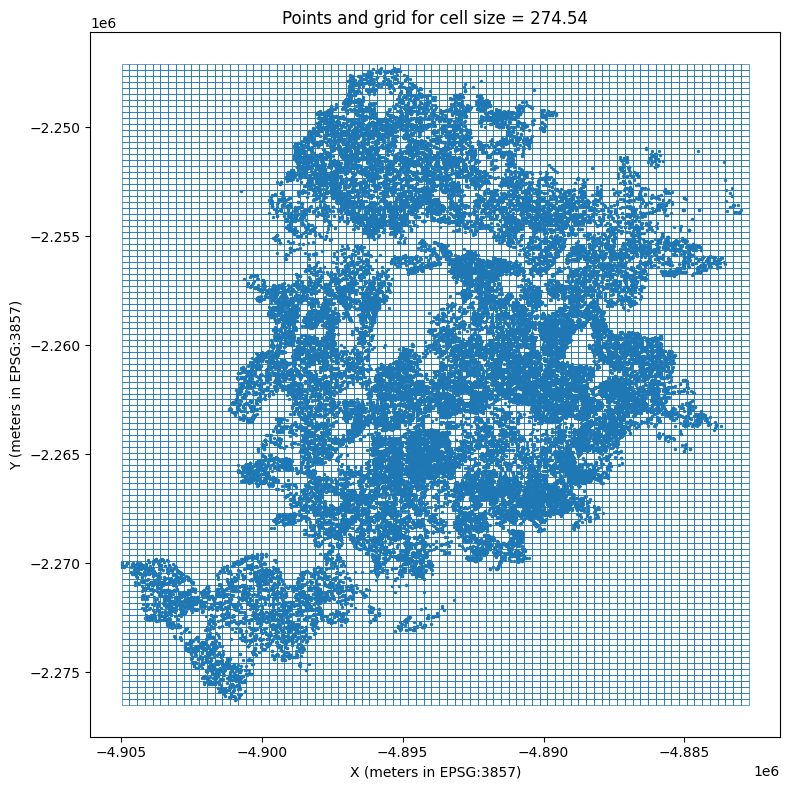

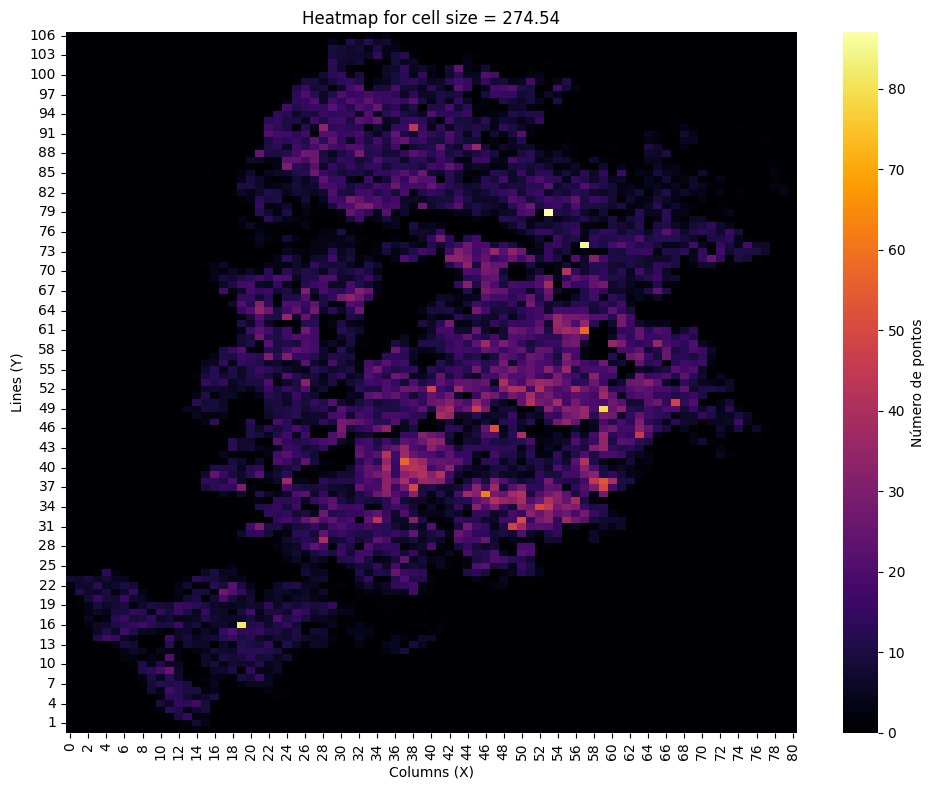

HeatmapStats(mean_all_cells=np.float64(5.141340717664705), mean_nonzero_cells=11.571020514152169)


In [32]:
optimal_scale = optimal_granularity.optimal_scale
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)

# Fires confirmed 2023 Minneapolis

In [ ]:
shapefile_path = "../data/fires_confirmed_2023_minneapolis/Fires_Confirmed_2023.shp"

coords, gdf_coords = load_shapefile_points(shapefile_path)

In [ ]:
mean_x = np.mean(coords[:, 0])
mean_y = np.mean(coords[:, 1])

dist_from_mean = np.sqrt((coords[:, 0] - mean_x) ** 2 + (coords[:, 1] - mean_y) ** 2)

outlier_indices = np.argsort(dist_from_mean)[-3:]
outlier_coords = coords[outlier_indices]

coords_clean = np.delete(coords, outlier_indices, axis=0)
gdf_coords_clean = gdf_coords.drop(gdf_coords.index[outlier_indices]).reset_index(drop=True)

coords = coords_clean
gdf_coords = gdf_coords_clean

In [ ]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=8,
    signif=0.99,
    uniformity_method="quadrat_count",
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    # verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/fires-minneapolis/results-qc.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

In [ ]:
optimal_scale = optimal_granularity.optimal_scale
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)

In [ ]:
gdf_coords.shape

# Public Incidents Minneapolis

In [ ]:
shapefile_path = "../data/public_incidents_minneapolis/Public_311_Incidents_2020.shp"

coords, gdf_coords = load_shapefile_points(shapefile_path)

In [ ]:
mean_x = np.mean(coords[:, 0])
mean_y = np.mean(coords[:, 1])

dist_from_mean = np.sqrt((coords[:, 0] - mean_x) ** 2 + (coords[:, 1] - mean_y) ** 2)

outlier_indices = np.argsort(dist_from_mean)[-19034:]
outlier_coords = coords[outlier_indices]

coords_clean = np.delete(coords, outlier_indices, axis=0)
gdf_coords_clean = gdf_coords.drop(gdf_coords.index[outlier_indices]).reset_index(drop=True)

coords = coords_clean
gdf_coords = gdf_coords_clean

In [ ]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=8,
    signif=0.99,
    uniformity_method="quadrat_count",
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    # verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/public-incidents-minneapolis/results-qc.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

In [ ]:
gdf_coords[:-10]

In [ ]:
optimal_scale = optimal_granularity.optimal_scale
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)